In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("C:/Users/arman/ostad_code")

In [3]:
df=pd.read_csv("OnlineRetail.csv",encoding="unicode_escape")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# RFM = Recency Frequency Moneytory,,,amader akn ai 3ta bar korte hbe model bananor jonne

In [4]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [5]:
###amra data type dakhlam but akane date o string dekasse,,,tai amra date ta k date a convert korbo,,

In [6]:
currentDate=pd.to_datetime("2012-01-01")
currentDate

Timestamp('2012-01-01 00:00:00')

In [7]:
###amra 2012-01-01 atake ajker date dorsi ,,jar karone amader recency kom asbe,,nahole 2011 sal theke ajker 26 projponto onk recency asto

In [8]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df
##amader invoice date ta to string a selo,,setake date a convert kore invoicedate column a e raksi

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [9]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [10]:
max_date=df.groupby("CustomerID").max()
max_date

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
CustomerID,,,,,,,
12346.0,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:17:00,1.04,United Kingdom
12347.0,581180,85232D,WOODLAND DESIGN COTTON TOTE BAG,240,2011-12-07 15:52:00,12.75,Iceland
12348.0,568172,POST,SWEETIES STICKERS,144,2011-09-25 13:13:00,40.00,Finland
12349.0,577609,POST,ZINC FOLKART SLEIGH BELLS,36,2011-11-21 09:51:00,300.00,Italy
12350.0,543037,POST,UNION JACK FLAG PASSPORT COVER,24,2011-02-02 16:01:00,40.00,Norway
...,...,...,...,...,...,...,...
18280.0,545712,82484,WOODEN UNION JACK BUNTING,8,2011-03-07 09:52:00,9.95,United Kingdom
18281.0,556464,23209,ROBOT BIRTHDAY CARD,12,2011-06-12 10:53:00,16.95,United Kingdom
18282.0,C562808,23295,SET OF 12 MINI LOAF BAKING CASES,48,2011-12-02 11:43:00,12.75,United Kingdom


In [11]:
max_date=df.groupby("CustomerID").max()[["InvoiceDate"]]
max_date

,InvoiceDate
CustomerID,
12346.0,2011-01-18 10:17:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00
...,...
18280.0,2011-03-07 09:52:00
18281.0,2011-06-12 10:53:00
18282.0,2011-12-02 11:43:00


In [12]:
gh=(currentDate-max_date["InvoiceDate"]).dt.days
gh

CustomerID
12346.0    347
12347.0     24
12348.0     97
12349.0     40
12350.0    332
          ... 
18280.0    299
18281.0    202
18282.0     29
18283.0     25
18287.0     64
Name: InvoiceDate, Length: 4372, dtype: int64

In [13]:
max_date["invoice age"]=gh

In [14]:
max_date

,InvoiceDate,invoice age
CustomerID,,
12346.0,2011-01-18 10:17:00,347
12347.0,2011-12-07 15:52:00,24
12348.0,2011-09-25 13:13:00,97
12349.0,2011-11-21 09:51:00,40
12350.0,2011-02-02 16:01:00,332
...,...,...
18280.0,2011-03-07 09:52:00,299
18281.0,2011-06-12 10:53:00,202
18282.0,2011-12-02 11:43:00,29


In [15]:
recency=max_date.drop('InvoiceDate',axis=1)
recency

,invoice age
CustomerID,
12346.0,347
12347.0,24
12348.0,97
12349.0,40
12350.0,332
...,...
18280.0,299
18281.0,202
18282.0,29


# akn amra frequency bar korbo,,,mane akta customer highest koto bar kinse

In [16]:
freq=df.drop_duplicates(subset="InvoiceNo")
freq
#jehetu akta customer onk gula invoice korse tai akta customer ar akta invoice rakhbo,,duplicate invoice remove kore debo

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom
25,536369,21756,BATH BUILDING BLOCK WORD,3,2010-12-01 08:35:00,5.95,13047.0,United Kingdom
...,...,...,...,...,...,...,...,...
541865,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom
541869,581585,22481,BLACK TEA TOWEL CLASSIC DESIGN,12,2011-12-09 12:31:00,0.39,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom


In [17]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [18]:
freq=freq.groupby(["CustomerID"]).count()[["InvoiceNo"]]
freq
#akta customer sorbocco kotota invoice korese tai dakhbo

,InvoiceNo
CustomerID,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,3


# akn amra monetory bar korbo,,mane akta customer highest koto takar invoice korse

In [19]:
df["total"]=df["Quantity"]*df["UnitPrice"]
df
#akane amra bar korsi akta customer ar invoice quantity ar sathe invoice price ba unit price ar gun dese

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [20]:
money=df.groupby(["CustomerID"])[["total"]].sum()
money
#akane customer id dhore groupby kore total amount ta k sum kore dese,,prottekta customer ar total ta k sum korsi

,total
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,176.60


In [21]:
# 12346 ai customer ar total  invoice amount zero ase,,ar invoice number 2ta ase,,karon se akbar kine,, ar akbar ferot dese

In [22]:
df[df["CustomerID"]==12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6


In [23]:
RFM=pd.concat([recency,freq,money],axis=1)
RFM
# akane amra recency frequncy ar monetory concat kore ak sathe korsi

,invoice age,InvoiceNo,total
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


In [24]:
RFM.columns=["Recency","Frequency","Monetary"]
RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled=scaler.fit_transform(RFM)

In [26]:
scaled

array([[ 2.31656788, -0.32936215, -0.23100099],
       [-0.88904975,  0.20610242,  0.29343167],
       [-0.16456032, -0.11517632, -0.01231622],
       ...,
       [-0.83942719, -0.22226923, -0.20951263],
       [-0.87912524,  1.16993863,  0.02390005],
       [-0.49206924, -0.22226923, -0.00744423]])

In [27]:
scaled=pd.DataFrame(data=scaled)
scaled

,0,1,2
0,2.316568,-0.329362,-0.231001
1,-0.889050,0.206102,0.293432
2,-0.164560,-0.115176,-0.012316
3,-0.730258,-0.436455,-0.017146
4,2.167700,-0.436455,-0.190312
...,...,...,...
4367,1.840191,-0.436455,-0.209026
4368,0.877514,-0.436455,-0.221167
4369,-0.839427,-0.222269,-0.209513
4370,-0.879125,1.169939,0.023900


In [28]:
scaled.shape

(4372, 3)

# Akn amra model implement korbo

In [29]:
from sklearn.cluster import KMeans

In [30]:
# aga k ar value bar kore nebo

In [31]:
k_range=range(1,10)
sse=[]  #akane sse name notun ar akta list nisi
for k in k_range: # k ar modde first a 1 jabe avabe 1to 9 obdi jabe k_range theke
    km=KMeans(n_clusters=k) #akta akta k ar man nebe ar seta deye cluster korbe
    km.fit(scaled)
    sse.append(km.inertia_) #akane inertia ar maddome some of squer error bar hobe ,,tar pore seta sse ar modde cole jabe

In [32]:
sse

[13116.000000000002,
 9134.642381209182,
 7526.473050697348,
 4046.6395856924664,
 3038.2506451982954,
 2383.630044136904,
 2040.3324960455775,
 1587.4535448461556,
 1426.9197899615183]

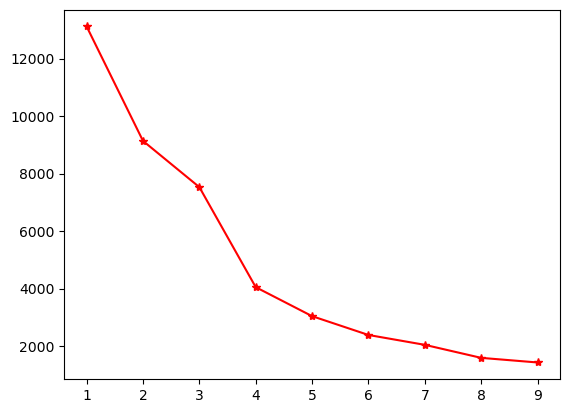

In [33]:
plt.plot(k_range,sse,"r-*")
plt.xlabel="k"
plt.ylabel="some of squre error"

In [34]:
#jekane dag ta vag porbe sekane e k ar man thake,,tar mane amader k ar man 3 bar holo

In [35]:
kmeans=KMeans(n_clusters=3)
kmeans.fit(scaled)

KMeans(n_clusters=3)

In [36]:
kmeans.labels_  #akane 0,1,2 ai 3ta vag a vag korse sob dat agula k

array([1, 0, 0, ..., 0, 0, 0], dtype=int32)

In [37]:
RFM["Clusters"]=(kmeans.labels_+1) #ak dap agaisi 0 hoise 1,,ar 1 hoise 2,ar 2 hoise 3,,tar pore seta clusters ar modde rakse
RFM

,Recency,Frequency,Monetary,Clusters
CustomerID,,,,
12346.0,347,2,0.00,2
12347.0,24,7,4310.00,1
12348.0,97,4,1797.24,1
12349.0,40,1,1757.55,1
12350.0,332,1,334.40,2
...,...,...,...,...
18280.0,299,1,180.60,2
18281.0,202,1,80.82,2
18282.0,29,3,176.60,1


In [38]:
RFM[RFM.Clusters==1] # 1 ar modde jengula ase tai dakhlam

,Recency,Frequency,Monetary,Clusters
CustomerID,,,,
12347.0,24,7,4310.00,1
12348.0,97,4,1797.24,1
12349.0,40,1,1757.55,1
12352.0,58,11,1545.41,1
12356.0,44,3,2811.43,1
...,...,...,...,...
18277.0,80,2,97.63,1
18278.0,95,1,173.90,1
18282.0,29,3,176.60,1


In [39]:
final=RFM.groupby("Clusters").mean()[["Recency","Frequency","Monetary"]]
final

,Recency,Frequency,Monetary
Clusters,,,
1,61.498765,5.597531,1823.319316
2,267.527502,1.853922,460.132111
3,27.521739,86.869565,81835.857391
